In [1]:
with open("corpus.txt", "r", encoding="utf-8") as f:
    corpus = f.read()

In [2]:
# character tokenizer

chars = sorted(list(set(corpus)))
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

In [3]:
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")
print(f"Characters: {''.join(chars)}")

Vocabulary size: 201
Characters: 	
 !"#$%&'()*+,-./0123456789:;<=>?@ABCDEFGHIJKLMNOPQRSTUVWXYZ[]^_abcdefghijklmnopqrstuvwxyz{|}~£·ÀÁÄÆÇÈÉËÍÒÖÚàáâäæçèéêëíîïñòóôöùúûüÿĩŒœΑΕΠΣΤΦΧάέήίαβγδεζηθικλμνξοπρςστυφχωόύώἀἄἅἐἔἥὀὁὍὐὑὗὰὲὴὶὸῖῦῶ–—‘’“”•™


In [4]:
import torch
import torch.nn as nn

# the transformer block with a triangular causal mask, no flash attention

class TransformerBlockManual(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, n_heads,
                                          batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        normed = self.ln1(x)
        x = x + self.drop(
            self.attn(normed, normed, normed, attn_mask=mask)[0])
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(),
            nn.Linear(d_ff, d_model))
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape

        normed = self.ln1(x)

        q = self.W_q(normed)
        k = self.W_k(normed)
        v = self.W_v(normed)

        q = q.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        attn = torch.nn.functional.scaled_dot_product_attention(
            q, k, v, dropout_p=self.drop.p, is_causal=True)

        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        attn = self.W_o(attn)

        x = x + self.drop(attn)
        x = x + self.drop(self.ff(self.ln2(x)))
        return x

In [6]:
def make_causal_mask(seq_len, device):
    # matrix where future positions are masked out
    mask = torch.triu(torch.ones(seq_len, seq_len, device=device), diagonal=1)
    mask = mask.masked_fill(mask == 1, float('-inf'))
    return mask

In [7]:
class GPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, d_ff, context_len, dropout=0.1, use_flash=True):
        super().__init__()
        self.use_flash = use_flash
        self.token_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(context_len, d_model)
        self.drop = nn.Dropout(dropout)

        block_class = TransformerBlock if use_flash else TransformerBlockManual
        self.blocks = nn.ModuleList([
            block_class(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        seq_len = x.shape[1]
        positions = torch.arange(seq_len, device=x.device)
        x = self.drop(self.token_emb(x) + self.pos_emb(positions))

        if self.use_flash:
            for block in self.blocks:
                x = block(x)
        else:
            mask = make_causal_mask(seq_len, x.device)
            for block in self.blocks:
                x = block(x, mask=mask)

        x = self.ln_final(x)
        return self.head(x)

In [8]:
context_len = 256

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = GPT(vocab_size, 256, 8, 6, 1024, 256).to(device)  # with flash attention

In [10]:
# encode the entire corpus
data = torch.tensor([char_to_idx[c] for c in corpus], dtype=torch.long)

# train/validation split (90/10)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

print(f"Train tokens: {len(train_data)}")
print(f"Val tokens: {len(val_data)}")

Train tokens: 4882914
Val tokens: 542546


In [11]:
def get_batch(data, batch_size, context_len, device):
    ix = torch.randint(len(data) - context_len, (batch_size,))
    x = torch.stack([data[i:i+context_len] for i in ix])
    y = torch.stack([data[i+1:i+context_len+1] for i in ix])
    return x.to(device), y.to(device)

In [12]:
from google.colab import files

def generate(model, prompt, max_new_chars, device, temperature=1.0):
    model.eval()

    x = torch.tensor([char_to_idx[c] for c in prompt], dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        for _ in range(max_new_chars):

            x_crop = x[:, -context_len:]
            logits = model(x_crop)

            logits = logits[:, -1, :] / temperature
            probs = torch.nn.functional.softmax(logits, dim=-1)
            next_char = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_char], dim=1)

    return ''.join([idx_to_char[i.item()] for i in x[0]])

In [13]:
from tqdm.notebook import tqdm
from google.colab import files

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer,
    lambda step: min(1.0, (step + 1) / 1000))

loss_fn = nn.CrossEntropyLoss()
n_steps = 20_000

train_losses = []
val_losses = []

for step in tqdm(range(1, n_steps + 1)):
    model.train()
    x_train, y_train = get_batch(train_data, 64, 256, device)

    logits = model(x_train)
    loss = loss_fn(logits.view(-1, vocab_size), y_train.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    scheduler.step()

    train_loss = loss.item()

    if step % 250 == 0:
        model.eval()
        val_loss=0
        with torch.no_grad():
            for _ in range(5):  # average over 5 batches
                x_val, y_val = get_batch(val_data, 64, 256, device)
                val_logits = model(x_val)
                val_loss += loss_fn(
                    val_logits.view(-1, vocab_size),
                    y_val.view(-1)
                ).item()

        val_loss /= 5
        val_bpc = val_loss / 0.6931

        print(f"\nstep {step} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | val bpc {val_bpc:.4f}\n")
        train_losses.append(train_loss)
        val_losses.append(val_loss)

    if step % 2000 == 0:
        sample = generate(model, prompt="<book>\n", max_new_chars=300, device=device)
        print(f"\n{sample}\n")
        # checkpoint regularly
        torch.save(model.state_dict(), "model_extended_dataset.pt")
        files.download('model_extended_dataset.pt')

  0%|          | 0/20000 [00:00<?, ?it/s]


step 250 | train loss 2.7314 | val loss 2.7426 | val bpc 3.9570


step 500 | train loss 2.4769 | val loss 2.4675 | val bpc 3.5601


step 750 | train loss 2.3131 | val loss 2.3185 | val bpc 3.3451


step 1000 | train loss 2.1140 | val loss 2.1170 | val bpc 3.0544


step 1250 | train loss 2.0301 | val loss 2.0067 | val bpc 2.8952


step 1500 | train loss 1.9707 | val loss 1.9086 | val bpc 2.7537


step 1750 | train loss 1.9421 | val loss 1.8221 | val bpc 2.6290


step 2000 | train loss 1.8939 | val loss 1.8030 | val bpc 2.6013


<book>
   I's spequante as peasss 'at littler
                   847
Dress the knows teverfurd and with to ve is irknown
     Ine his was left it yelk smull say,
   At daid my "sun our rest, abil and mile."



I shot any, and seatt the reown, downer,
   Caye thing a thear, on though me
ce’l the with nor se



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


step 2250 | train loss 1.7636 | val loss 1.7460 | val bpc 2.5191


step 2500 | train loss 1.8043 | val loss 1.6970 | val bpc 2.4484


step 2750 | train loss 1.7610 | val loss 1.6862 | val bpc 2.4328


step 3000 | train loss 1.7688 | val loss 1.6506 | val bpc 2.3815


step 3250 | train loss 1.6714 | val loss 1.6329 | val bpc 2.3559


step 3500 | train loss 1.6778 | val loss 1.5703 | val bpc 2.2656


step 3750 | train loss 1.6694 | val loss 1.5537 | val bpc 2.2417


step 4000 | train loss 1.6617 | val loss 1.5517 | val bpc 2.2388


<book>




THE PAUSTLES, little Love was so know,
   "I iggon love that a was stall
  "DropEd hand nampoun was a hill,
  "'Ah now, our was never sort I do groom.
"Aland you harnit with suddes in much mind,
  And you soul," I caming hear;
My grove has not a wayed bind on,
"God for all I have advid I brays."



...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


step 18250 | train loss 1.2399 | val loss 1.2488 | val bpc 1.8018


step 18500 | train loss 1.2278 | val loss 1.2585 | val bpc 1.8158


step 18750 | train loss 1.2749 | val loss 1.2301 | val bpc 1.7748


step 19000 | train loss 1.2026 | val loss 1.2465 | val bpc 1.7985


step 19250 | train loss 1.2337 | val loss 1.2265 | val bpc 1.7695


step 19500 | train loss 1.2282 | val loss 1.2525 | val bpc 1.8071


step 19750 | train loss 1.2633 | val loss 1.2433 | val bpc 1.7938


step 20000 | train loss 1.2214 | val loss 1.2149 | val bpc 1.7528


<book>


  NELLY GROSS NAP VIRGIN IN CHANCE

  The flew was returned
  Out (O grove 'twas what any Squeezi.)

  Princessumed the all Indian host,
  He laughed a weader from greezing hist
  Of the reasure that he lost Papa.'
             Oh! let us doubt.
  The day changed the unswern call,
  "'Tis has guil



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

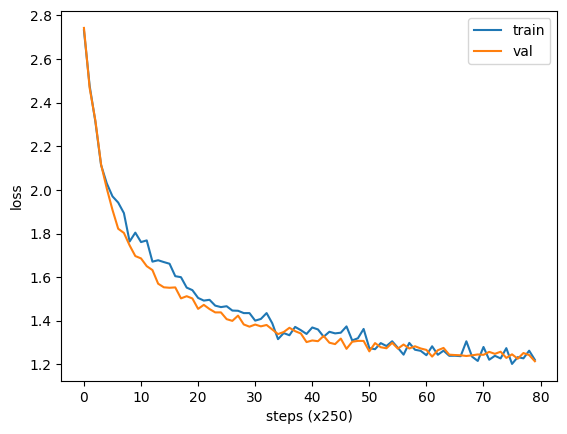

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend()
plt.xlabel('steps (x250)')
plt.ylabel('loss')
plt.show()